In [1]:
pip install xgboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 15.3 MB/s eta 0:00:00


In [2]:
pip install datasets

In [3]:
from datasets import load_dataset

ds = load_dataset("mahmoudalyosify/SCRAP")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/399 [00:00<?, ?B/s]

train_data.csv:   0%|          | 0.00/234M [00:00<?, ?B/s]

test_data.csv:   0%|          | 0.00/35.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/162634 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24484 [00:00<?, ? examples/s]

In [4]:
pip install xgboost seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split,cross_val_score,GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,mean_squared_error
import optuna
pd.set_option('display.max_columns', None, 'display.max_rows', None)

In [6]:
df_train=pd.DataFrame(ds['train'])
df_test=pd.DataFrame(ds['test'])


In [7]:
df_train.head()

,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,relative_position_n,relative_velocity_r,relative_velocity_t,relative_velocity_n,t_time_lastob_start,t_time_lastob_end,t_recommended_od_span,t_actual_od_span,t_obs_available,t_obs_used,t_residuals_accepted,t_weighted_rms,t_rcs_estimate,t_cd_area_over_mass,t_cr_area_over_mass,t_sedr,t_j2k_sma,t_j2k_ecc,t_j2k_inc,t_ct_r,t_cn_r,t_cn_t,t_crdot_r,t_crdot_t,t_crdot_n,t_ctdot_r,t_ctdot_t,t_ctdot_n,t_ctdot_rdot,t_cndot_r,t_cndot_t,t_cndot_n,t_cndot_rdot,t_cndot_tdot,c_object_type,c_time_lastob_start,c_time_lastob_end,c_recommended_od_span,c_actual_od_span,c_obs_available,c_obs_used,c_residuals_accepted,c_weighted_rms,c_rcs_estimate,c_cd_area_over_mass,c_cr_area_over_mass,c_sedr,c_j2k_sma,c_j2k_ecc,c_j2k_inc,c_ct_r,c_cn_r,c_cn_t,c_crdot_r,c_crdot_t,c_crdot_n,c_ctdot_r,c_ctdot_t,c_ctdot_n,c_ctdot_rdot,c_cndot_r,c_cndot_t,c_cndot_n,c_cndot_rdot,c_cndot_tdot,t_span,c_span,t_h_apo,t_h_per,c_h_apo,c_h_per,geocentric_latitude,azimuth,elevation,mahalanobis_distance,t_position_covariance_det,c_position_covariance_det,t_sigma_r,c_sigma_r,t_sigma_t,c_sigma_t,t_sigma_n,c_sigma_n,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,1.566798,5,-10.204955,-7.834756,8.602101,14923.0,13792.0,453.8,5976.6,-13666.8,-7.2,-12637.0,-5525.9,1.0,0.0,3.78,3.78,459,458,98.9,1.265,0.402,0.013826,0.007173,0.000051,6996.918867,0.003997,97.806412,-0.397969,0.292258,0.040799,0.394221,-0.999674,-0.038498,-0.981098,0.214612,-0.316493,-0.210247,0.170737,-0.001551,0.531593,0.002117,-0.179278,UNKNOWN,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.36,NaN,0.348701,0.126607,0.001406,7006.607320,0.003144,74.045735,-0.824859,0.473976,-0.002576,0.825216,-0.999998,0.003565,-0.732954,0.220006,-0.814249,-0.220621,0.249855,0.196620,0.722186,-0.196908,-0.668487,1.0,2.0,646.745439,590.818294,650.497251,606.443389,-73.574095,-23.618769,0.029910,129.430951,737347.125225,4.429923e+16,4.057932,266.722309,137.617114,54366.864909,1.781418,46.612573,0.147350,58.272095,0.004092,0.165044,0.002987,0.386462,89.0,83.0,42.0,11.0
1,0,1.207494,5,-10.355758,-7.848937,8.956374,14544.0,13792.0,474.3,5821.2,-13319.8,-7.0,-12637.0,-5525.9,1.0,0.0,3.79,3.79,456,455,98.5,1.270,0.402,0.013487,0.009139,0.000060,6996.920255,0.003996,97.806420,-0.073137,0.297366,0.060541,0.069652,-0.998192,-0.052511,-0.994240,-0.029644,-0.302333,0.034030,0.179696,0.001552,0.561142,-0.005165,-0.181036,UNKNOWN,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.36,NaN,0.348701,0.126607,0.001406,7006.621053,0.003144,74.045736,-0.818207,0.482754,-0.003578,0.818573,-0.999998,0.004574,-0.728759,0.202595,-0.817490,-0.203216,0.258964,0.195718,0.721903,-0.196008,-0.674979,1.0,2.0,646.743506,590.823004,650.513314,606.454793,-73.570690,-23.618769,0.029079,271.540424,114138.993569,4.378610e+16,3.526780,262.191819,56.070117,54082.067268,1.800959,46.595869,0.059672,57.966413,0.003753,0.164383,0.002933,0.386393,89.0,83.0,42.0,11.0
2,0,0.952193,5,-10.345631,-7.847406,8.932195,14475.0,13792.0,474.6,5796.2,-13256.1,-7.0,-12637.0,-5525.9,1.0,0.0,3.79,3.80,456,455,98.5,1.257,0.402,0.013357,0.007057,0.000060,6996.920553,0.003996,97.806418,-0.109230,0.305189,0.043711,0.107079,-0.996235,-0.034287,-0.996674,0.033933,-0.308501,-0.030161,0.123760,0.019630,0.579274,-0.023726,-0.125737,UNKNOWN,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.36,NaN,0.348701,0.126607,0.001406,7006.623524,0.003144,74.045737,-0.817408,0.483828,-0.003742,0.817774,-0.999998,0.004738,-0.729083,0.201698,-0.817662,-0.202320,0.260092,0.195558,0.721854,-0.195849,-0.675347,1.0,2.0,646.745607,590.821499,650.515082,606.457965,-73.570088,-23.618769,0.029079,347.899292,46960.041117,4.369105e+16,3.362037,261.666544,37.497947,54027.391201,1.821940,46.592757,0.039258,57.907599,0.003576,0.164352,0.002967,0.386381,89.0,83.0,42.0,11.0
3,0,0.579669,5,-10.337809,-7.845880,8.913444,14579.0,13792.0,472.7,5838.9,-13350.7,-7.0,-12637.0,-552

In [8]:
def preprocessing(df):
  num_cols = df.select_dtypes(include='number').columns
  df[num_cols] = df[num_cols].fillna(df[num_cols].median())
  df['c_object_type']=df['c_object_type'].fillna(df['c_object_type'].mode()[0])
  mapping = {
    'UNKOWN': 1,
    'TBA': 2,
    'ROCKET BODY': 3,
    'PAYLOAD':4,
    'DEBRIS':5
  }
  df['c_object_type']=df['c_object_type'].map(mapping)
  return df

In [9]:
def filtering (df):
  train=df[df['time_to_tca']>=2]
  train = train.sort_values(['event_id', 'time_to_tca'], ascending=[True, False])
  feature=train.drop(columns=['event_id','risk'])
  groups = train.groupby("event_id")
  return feature,groups

In [10]:
def feature_engineering(groups, feature):
    features = []
    targets = []

    for eid, g in groups:
        g = g.sort_values('time_to_tca', ascending=False)

        first = g.iloc[0]
        last  = g.iloc[-1]
        feat = {}

        targets.append(last['risk'])

        dt = first['time_to_tca'] - last['time_to_tca']
        dt = max(dt, 1e-6)

        for col in feature:
            if col in ['mission_id', 'c_object_type']:
                feat[col + "_last"] = last[col]
                continue
            if len(g) < 2:          # singleton group
                feat[col + "_last"]   = last[col]
                feat[col + "_mean"]   = last[col]
                feat[col + "_std"]    = 0.0
                feat[col + "_min"]    = last[col]
                feat[col + "_max"]    = last[col]
                feat[col + "_delta"]  = 0.0
                feat[col + "_slope"]  = 0.0
                continue

            feat[col + "_last"] = last[col]
            feat[col + "_mean"] = g[col].mean()
            feat[col + "_std"]  = g[col].std()
            feat[col + "_min"]  = g[col].min()
            feat[col + "_max"]  = g[col].max()
            feat[col + "_delta"] = last[col] - first[col]
            feat[col + "_slope"] = (last[col] - first[col]) / dt

        features.append(feat)

    X = pd.DataFrame(features)
    y = np.array(targets)

    return X, y


In [11]:
df_test=preprocessing(df_test)
df_train=preprocessing(df_train)

In [12]:
f,g=filtering(df_test)
m,n=filtering(df_train)

In [13]:
X_test,y_test=feature_engineering(g,f)
X_train,y_train=feature_engineering(n,m)

In [14]:
y_train = np.log(-y_train + 1e-8)
y_test  = np.log(-y_test + 1e-8)

In [15]:
y_train_1D = pd.DataFrame(np.squeeze(y_train))
y_test_1D  = np.squeeze(y_test)
X_train=X_train


count    13154.000000
mean        12.363844
std          7.512551
min          1.000000
25%          5.000000
50%         13.000000
75%         20.000000
max         23.000000
dtype: float64
                  0
count  11942.000000
mean       2.833272
std        0.617080
min        0.521563
25%        2.252186
50%        3.075714
75%        3.401197
max        3.401197


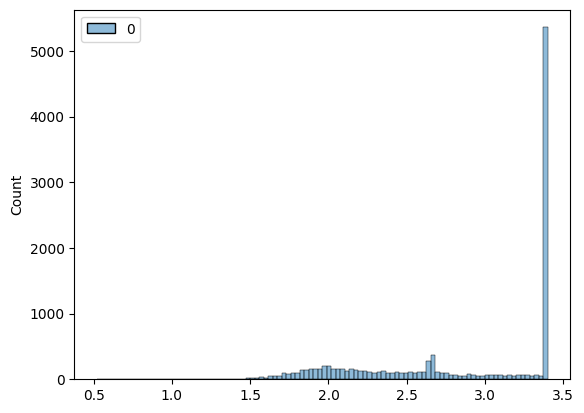

c_time_lastob_end_min        0.395865
c_time_lastob_end_last       0.392114
c_time_lastob_start_last     0.385987
time_to_tca_last             0.375079
time_to_tca_min              0.375079
time_to_tca_delta            0.368805
c_time_lastob_start_min      0.357971
time_to_tca_std              0.336534
c_time_lastob_end_mean       0.311878
c_time_lastob_start_mean     0.292637
c_ct_r_std                   0.288337
mahalanobis_distance_last    0.285189
c_crdot_r_std                0.274608
c_cn_r_std                   0.269620
max_risk_estimate_delta      0.267419
c_cndot_r_std                0.258606
c_time_lastob_end_delta      0.253808
c_cndot_tdot_std             0.253264
c_ctdot_rdot_std             0.247069
c_time_lastob_start_delta    0.244726
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [16]:
print(df_train.groupby('event_id').size().describe())  # how many obs per event?
print(y_train_1D.describe())                              # risk is heavily negative → maybe log-transform?
sns.histplot(y_train_1D, bins=100)
plt.show()

# Correlation with target
corr = X_train.corrwith(pd.Series(y_train)).abs().sort_values(ascending=False)
print(corr.head(20))

In [17]:
import numpy as np
import pandas as pd

print("inf---------------------",np.isinf(X_train).sum())

print("none---------------------",np.isnan(X_train).sum())

print("max----------------------",np.max(np.abs(X_train)))
X_train.fillna(X_train.mode().iloc[0],inplace=True)

inf--------------------- time_to_tca_last                   0
time_to_tca_mean                   0
time_to_tca_std                    0
time_to_tca_min                    0
time_to_tca_max                    0
time_to_tca_delta                  0
time_to_tca_slope                  0
mission_id_last                    0
max_risk_estimate_last             0
max_risk_estimate_mean             0
max_risk_estimate_std              0
max_risk_estimate_min              0
max_risk_estimate_max              0
max_risk_estimate_delta            0
max_risk_estimate_slope            0
max_risk_scaling_last              0
max_risk_scaling_mean              0
max_risk_scaling_std               0
max_risk_scaling_min               0
max_risk_scaling_max               0
max_risk_scaling_delta             0
max_risk_scaling_slope             0
miss_distance_last                 0
miss_distance_mean                 0
miss_distance_std                  0
miss_distance_min                  0
miss_distance

In [18]:
X_train = np.clip(X_train, -1e15, 1e15)

In [19]:
X_test = np.clip(X_test, -1e15, 1e15)

## importing gradient descent

In [25]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.8),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 20),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "tree_method": "hist",
        "device": "cuda",
        "random_state": 42
    }

    model = xgb.XGBRegressor(**params)

    # Use cross-validation to avoid overfitting to test set
    scores = cross_val_score(
            model, X_train, y_train.flatten(),
            cv=5,
            scoring="neg_root_mean_squared_error",
            groups=X_train['mission_id_last'],
            n_jobs=-1)

    return -scores.mean()  # Optuna minimizes, so negate

# Run
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Best results
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-02 21:24:36,229] A new study created in memory with name: no-name-ea5fa8b7-a79c-417d-85c8-76623a1c39b6


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(


[I 2026-03-02 21:24:55,848] Trial 0 finished with value: 0.043041222971910174 and parameters: {'n_estimators': 663, 'max_depth': 4, 'learning_rate': 0.047125829171371696, 'subsample': 0.7796504283419325, 'colsample_bytree': 0.5694210189134612, 'reg_lambda': 3.4467331858763974, 'reg_alpha': 0.13499476551345646, 'min_child_weight': 10, 'gamma': 0.39809851554085807}. Best is trial 0 with value: 0.043041222971910174.
[I 2026-03-02 21:25:11,961] Trial 1 finished with value: 0.036240684773362467 and parameters: {'n_estimators': 542, 'max_depth': 6, 'learning_rate': 0.05003747193290718, 'subsample': 0.7744792233384775, 'colsample_bytree': 0.6325401293907419, 'reg_lambda': 2.0412204379655314, 'reg_alpha': 0.6933487459915363, 'min_child_weight': 20, 'gamma': 0.23093826085748326}. Best is trial 1 with value: 0.036240684773362467.
[I 2026-03-02 21:25:27,578] Trial 2 finished with value: 0.058449739352122575 and parameters: {'n_estimators': 730, 'max_depth': 5, 'learning_rate': 0.0964768282481224,

In [26]:
best_params = study.best_params

final_model = xgb.XGBRegressor(
    **best_params,
    tree_method='hist',
    device='cuda',
    random_state=42
)

final_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7497126337811115, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.00019346219577405597, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.07063490289792276, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=8, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=554, n_jobs=None,
             num_parallel_tree=None, ...)

In [28]:
prediction=final_model.predict(X_test)
prediction = -np.exp(prediction) + 1e-8

In [29]:
y_train = -np.exp(y_train) + 1e-8
y_test  = -np.exp(y_test) + 1e-8

In [31]:
train_pred = final_model.predict(X_train)
train_pred = -np.exp(train_pred) + 1e-8
train_rmse = mean_squared_error(y_train, train_pred)**0.5
test_rmse = mean_squared_error(y_test, prediction)**0.5

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 0.1821735540358204
Test RMSE: 0.23358017658119357


In [32]:
from sklearn.metrics import precision_score, recall_score, mean_squared_error

def competition_loss(y_true, y_pred, beta=2):
    """
    Official competition loss: L = (1/F2) * MSE
    - Threshold: r >= -6 (log scale equivalent of 10^-6)
    - MSE: only on high-risk events
    - F2: over whole dataset
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    threshold = -6  # log10(10^-6) = -6

    # Step 1: Binary classification over whole dataset
    y_true_bin = (y_true >= threshold).astype(int)  # 1 = high risk
    y_pred_bin = (y_pred >= threshold).astype(int)

    # Step 2: F2 score
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall    = recall_score(y_true_bin, y_pred_bin, zero_division=0)

    if precision == 0 and recall == 0:
        f2 = 0
    else:
        f2 = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)

    # Step 3: MSE only on HIGH-RISK events
    high_risk_mask = y_true >= threshold

    if high_risk_mask.sum() == 0:
        print("Warning: No high-risk events found!")
        return float('inf')

    mse = mean_squared_error(
        y_true[high_risk_mask],
        y_pred[high_risk_mask]
    )

    # Step 4: Final loss
    if f2 == 0:
        loss = float('inf')
    else:
        loss = (1 / f2) * mse

    # Report
    print(f"Threshold:        r >= -6 (10^-6)")
    print(f"High-risk events: {high_risk_mask.sum()} / {len(y_true)}")
    print(f"Precision:        {precision:.4f}")
    print(f"Recall:           {recall:.4f}")
    print(f"F2 Score:         {f2:.4f}")
    print(f"MSE (high-risk):  {mse:.6f}")
    print(f"Final Loss L:     {loss:.6f}")

    return loss

# Evaluate
print("=== Test Set ===")
loss = competition_loss(y_test, prediction)


=== Test Set ===
Threshold:        r >= -6 (10^-6)
High-risk events: 178 / 2167
Precision:        0.9514
Recall:           0.9888
F2 Score:         0.9810
MSE (high-risk):  0.024379
Final Loss L:     0.024850
